In [4]:
from admixture_squarem import run_admixture_squarem

results = run_admixture_squarem(
    input_prefix="data_and_results/step2/intermediate/step2_admixture.pruned",
    output_folder="data_and_results/step2/results_squarem",
    k_values=[3],
    max_iters=1000,
    early_stop_rate=1e-6,
    random_seed=42,
    min_prob=1e-6,
    squarem_step_max=15.0,
)


Genotype summary:
Samples: 502 SNPs: 16712
477.0 501.9461464815701 502.0
Initial F summary:
0.5 0.8763278445895347 0.9899598393574297
0.4629990844090936 0.8763307252808693 1.024321985447193


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/tmp/ipykernel_105086/329562788.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("data_and_results/step2/results_squarem/step2_admixture.pruned.%s.Q"%K, delim_whitespace=True, header=None)


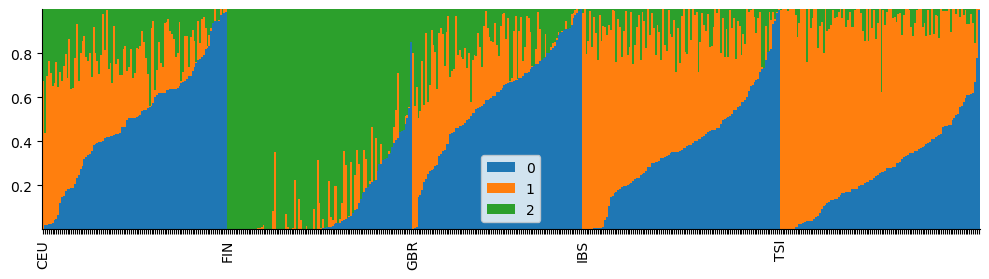

In [5]:
""" Check ADMIXTURE results """
%pylab inline

# The code below makes ADMIXTURE bar plots based on your results
# It will fail if your ADMIXTURE run was not complete or if you did not
# output results to the specified output files!
# Please ensure you get plots (and the notebook validates)
# to get full points.

import pandas as pd

sampleinfo = pd.read_csv("data_and_results/step2/dataset/igsr_samples.tsv", sep="\t")
sample_to_pop = dict(zip(list(sampleinfo["Sample name"]), list(sampleinfo["Population code"])))
samples = [line.split()[0] for line in open("data_and_results/step2/intermediate/step2_admixture.pruned.fam", "r").readlines()]
pops = [sample_to_pop.get(item, "NA") for item in samples]

fig = plt.figure()
fig.set_size_inches((10, 8))

plotind = 1
for K in [3]:
    ax = fig.add_subplot(3, 1, plotind)
    
    data = pd.read_csv("data_and_results/step2/results_squarem/step2_admixture.pruned.%s.Q"%K, delim_whitespace=True, header=None)
    cols = list(data.columns)
    data["sample"] = samples
    data["pop"] = pops
    data = data.sort_values(["pop"]+cols)
    data.plot.bar(stacked=True, ax=ax, width=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')
    
    # Only plot label for first sample in each pop
    xticklabels = []
    currpop = ""
    for i in range(data.shape[0]):
        if data["pop"].values[i] == currpop:
            xticklabels.append("")
        else:
            xticklabels.append(data["pop"].values[i])
            currpop = data["pop"].values[i]
    ax.set_xticklabels(xticklabels)
    
    plotind += 1
fig.tight_layout()

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/tmp/ipykernel_105086/168606294.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("data_and_results/step2/reference_results/step2_admixture.pruned.%s.Q"%K, delim_whitespace=True, header=None)


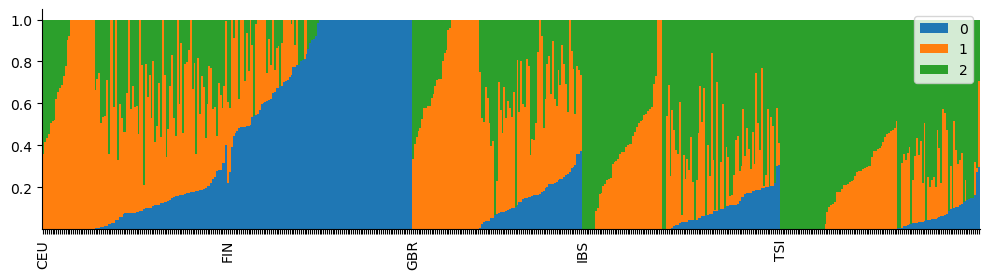

In [6]:
""" Check ADMIXTURE results """
%pylab inline

# The code below makes ADMIXTURE bar plots based on your results
# It will fail if your ADMIXTURE run was not complete or if you did not
# output results to the specified output files!
# Please ensure you get plots (and the notebook validates)
# to get full points.

import pandas as pd

sampleinfo = pd.read_csv("data_and_results/step2/dataset/igsr_samples.tsv", sep="\t")
sample_to_pop = dict(zip(list(sampleinfo["Sample name"]), list(sampleinfo["Population code"])))
samples = [line.split()[0] for line in open("data_and_results/step2/intermediate/step2_admixture.pruned.fam", "r").readlines()]
pops = [sample_to_pop.get(item, "NA") for item in samples]

fig = plt.figure()
fig.set_size_inches((10, 8))

plotind = 1
for K in [3]:
    ax = fig.add_subplot(3, 1, plotind)
    
    data = pd.read_csv("data_and_results/step2/reference_results/step2_admixture.pruned.%s.Q"%K, delim_whitespace=True, header=None)
    cols = list(data.columns)
    data["sample"] = samples
    data["pop"] = pops
    data = data.sort_values(["pop"]+cols)
    data.plot.bar(stacked=True, ax=ax, width=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')
    
    # Only plot label for first sample in each pop
    xticklabels = []
    currpop = ""
    for i in range(data.shape[0]):
        if data["pop"].values[i] == currpop:
            xticklabels.append("")
        else:
            xticklabels.append(data["pop"].values[i])
            currpop = data["pop"].values[i]
    ax.set_xticklabels(xticklabels)
    
    plotind += 1
fig.tight_layout()